# Análise de Vendas — Marketplace Olist

Análise exploratória sobre o comportamento de vendas, entrega e satisfação dos clientes no marketplace brasileiro **Olist**, com base no dataset público disponível no Kaggle (~100 mil pedidos, 2016-2018).

**Perguntas respondidas neste notebook:**
1. Como evoluíram o volume de pedidos e a receita ao longo do tempo?
2. Quais categorias de produto mais vendem?
3. O prazo de entrega afeta a nota que o cliente dá ao pedido?
4. Atrasos na entrega estão concentrados em transações interestaduais?
5. Qual o perfil do cliente: onde está, como paga, e qual seu nível de satisfação por estado?

**Ferramentas:** Python, Pandas, Seaborn/Matplotlib.


## 1. Preparação dos dados

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
pd.options.display.float_format = '{:.2f}'.format

DATA = "../data"

orders = pd.read_csv(f"{DATA}/olist_orders_dataset.csv")
customers = pd.read_csv(f"{DATA}/olist_customers_dataset.csv")
payments = pd.read_csv(f"{DATA}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{DATA}/olist_order_reviews_dataset.csv")
order_items = pd.read_csv(f"{DATA}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{DATA}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{DATA}/olist_sellers_dataset.csv")

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print(f"Pedidos: {len(orders):,} | Clientes: {len(customers):,} | Itens: {len(order_items):,} "
      f"| Produtos: {len(products):,} | Vendedores: {len(sellers):,}")
print(f"order_id duplicados: {orders['order_id'].duplicated().sum()}")

Pedidos: 99,441 | Clientes: 99,441 | Itens: 112,650 | Produtos: 32,951 | Vendedores: 3,095
order_id duplicados: 0


## 2. Evolução de vendas

Volume de pedidos e receita, mês a mês.

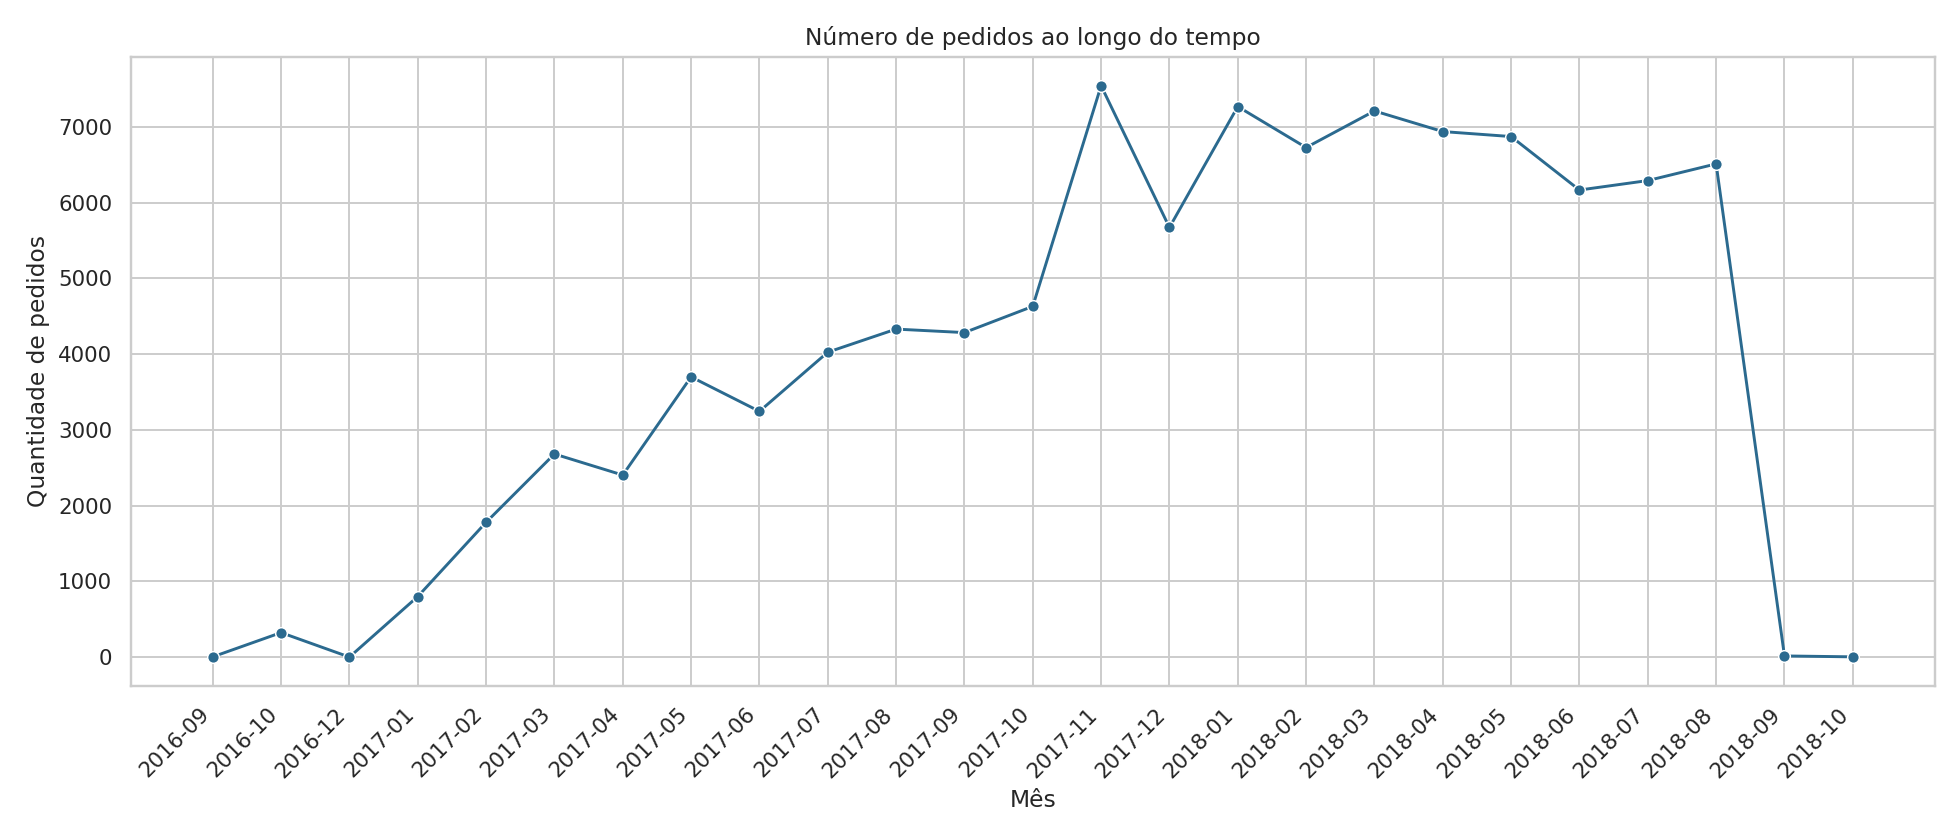

In [1]:
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
vendas_mensais = orders.groupby('year_month')['order_id'].nunique().reset_index()
vendas_mensais.columns = ['year_month', 'num_pedidos']

plt.figure(figsize=(14, 6))
sns.lineplot(data=vendas_mensais, x='year_month', y='num_pedidos', marker='o', color="#2b6a8f")
plt.xticks(rotation=45, ha='right')
plt.title('Número de pedidos ao longo do tempo')
plt.xlabel('Mês'); plt.ylabel('Quantidade de pedidos')
plt.tight_layout()
plt.show()

Receita total no período: R$ 13,591,643.70
Melhor mês: 2017-11 (R$ 1,010,271.37)


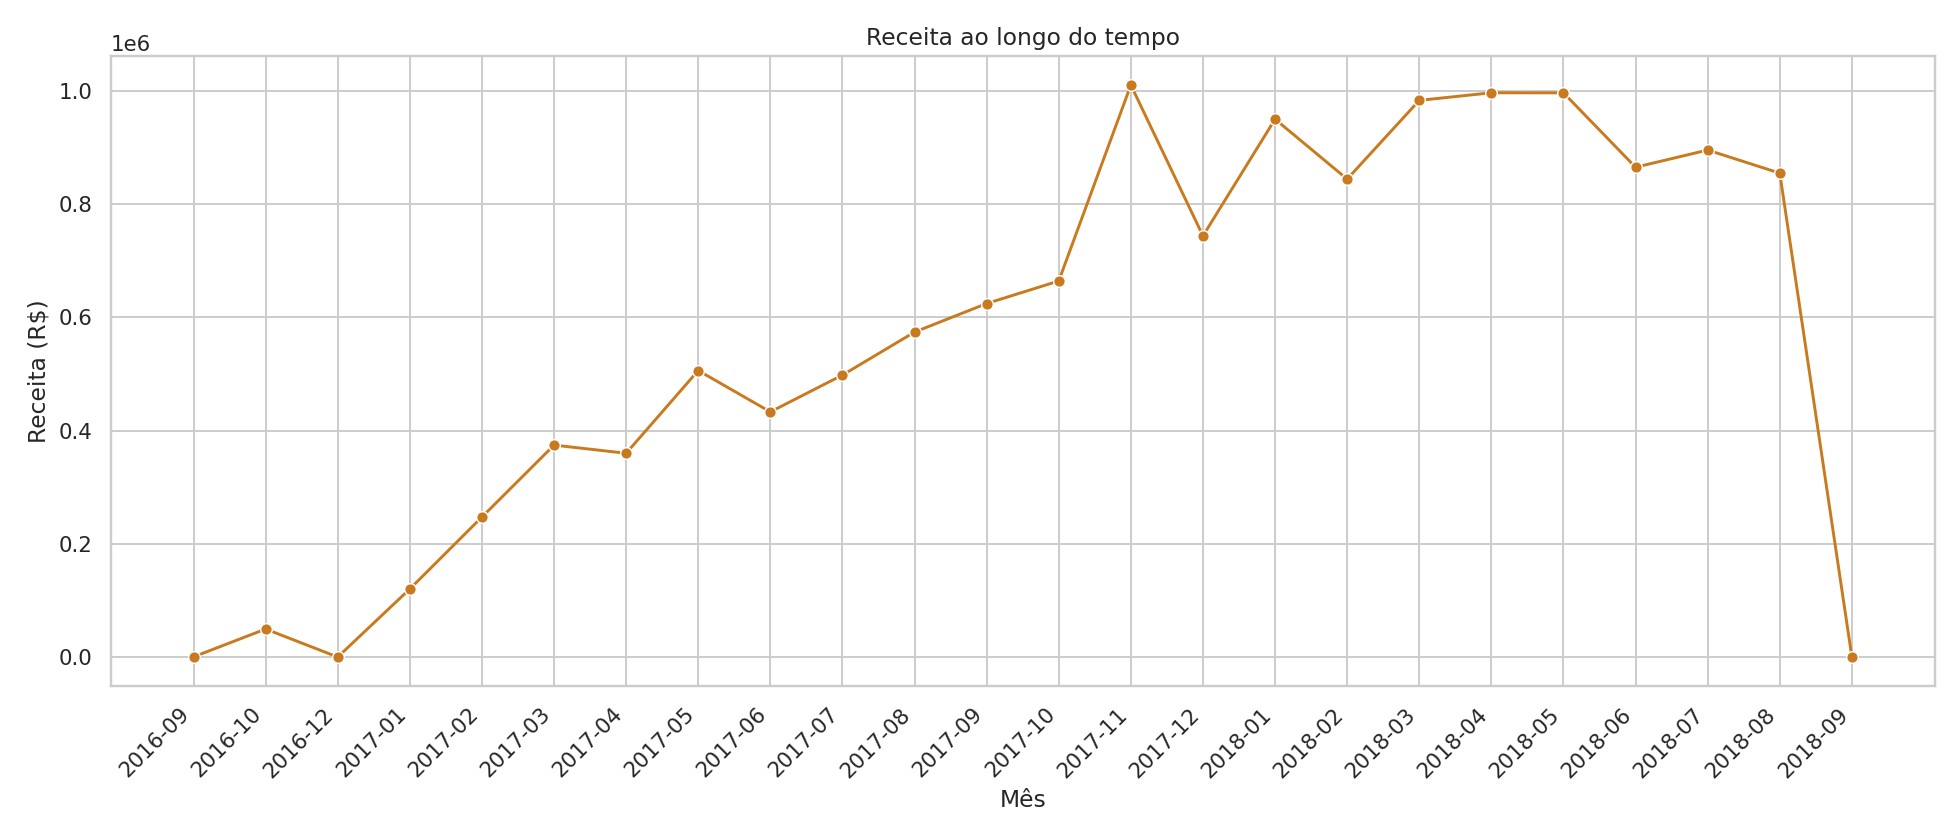

In [1]:
df_receita = pd.merge(orders, order_items, on='order_id')
receita_mensal = df_receita.groupby('year_month')['price'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=receita_mensal, x='year_month', y='price', marker='o', color="#c97a1f")
plt.xticks(rotation=45, ha='right')
plt.title('Receita ao longo do tempo')
plt.xlabel('Mês'); plt.ylabel('Receita (R$)')
plt.tight_layout()
plt.show()

print(f"Receita total no período: R$ {receita_mensal['price'].sum():,.2f}")
print(f"Melhor mês: {receita_mensal.loc[receita_mensal['price'].idxmax(), 'year_month']} "
      f"(R$ {receita_mensal['price'].max():,.2f})")

**Insight:** o volume de pedidos e a receita crescem de forma quase contínua entre 2016 e meados de 2018, com pico em novembro/2017 — coincide com a Black Friday. As quedas no início e no fim da série são artefatos de janelas incompletas de coleta de dados, não quedas reais de vendas.

## 3. Categorias de produto mais vendidas

 product_category_name  number_of_sales
       cama_mesa_banho            11115
          beleza_saude             9670
         esporte_lazer             8641
      moveis_decoracao             8334
informatica_acessorios             7827


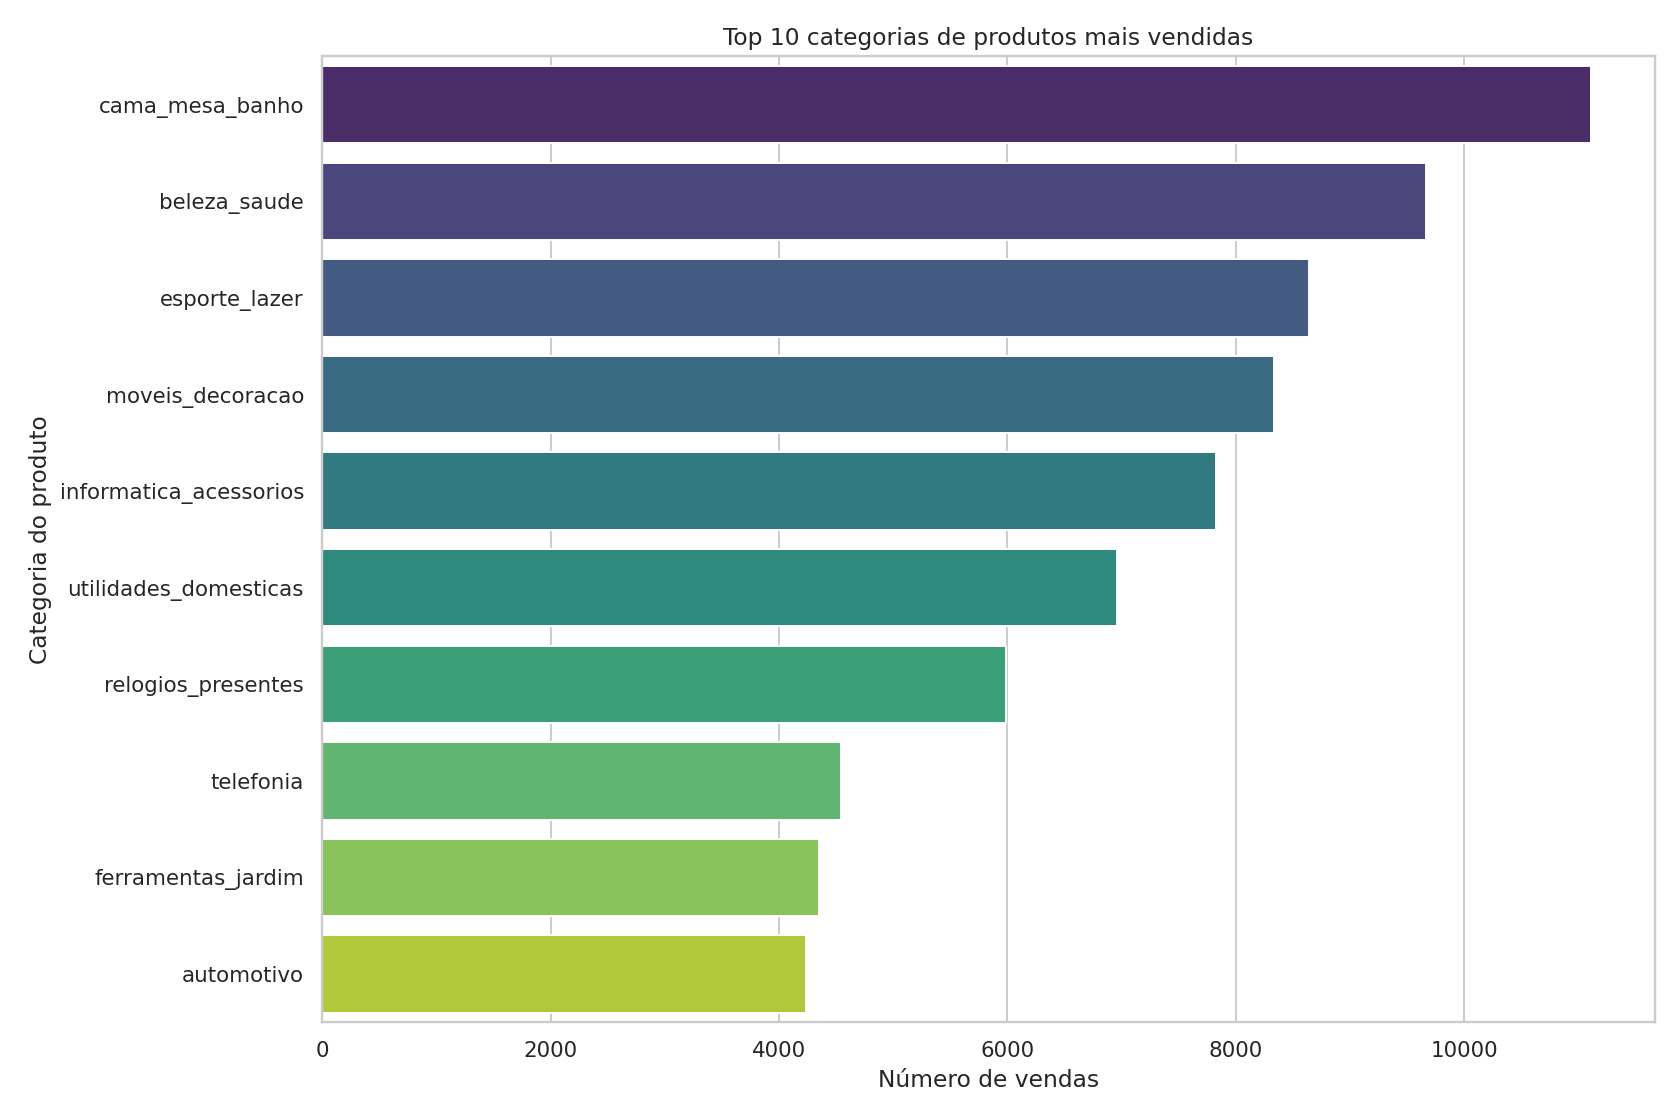

In [1]:
merged_items_products = pd.merge(order_items, products, on='product_id')
top_categories = merged_items_products['product_category_name'].value_counts().reset_index()
top_categories.columns = ['product_category_name', 'number_of_sales']

plt.figure(figsize=(12, 8))
sns.barplot(data=top_categories.head(10), x='number_of_sales', y='product_category_name',
            hue='product_category_name', palette='viridis', legend=False)
plt.title('Top 10 categorias de produtos mais vendidas')
plt.xlabel('Número de vendas'); plt.ylabel('Categoria do produto')
plt.tight_layout()
plt.show()

print(top_categories.head(5).to_string(index=False))

 product_category_name  numero_de_vendas  receita_total
          beleza_saude              9670     1258681.34
    relogios_presentes              5991     1205005.68
       cama_mesa_banho             11115     1036988.68
         esporte_lazer              8641      988048.97
informatica_acessorios              7827      911954.32


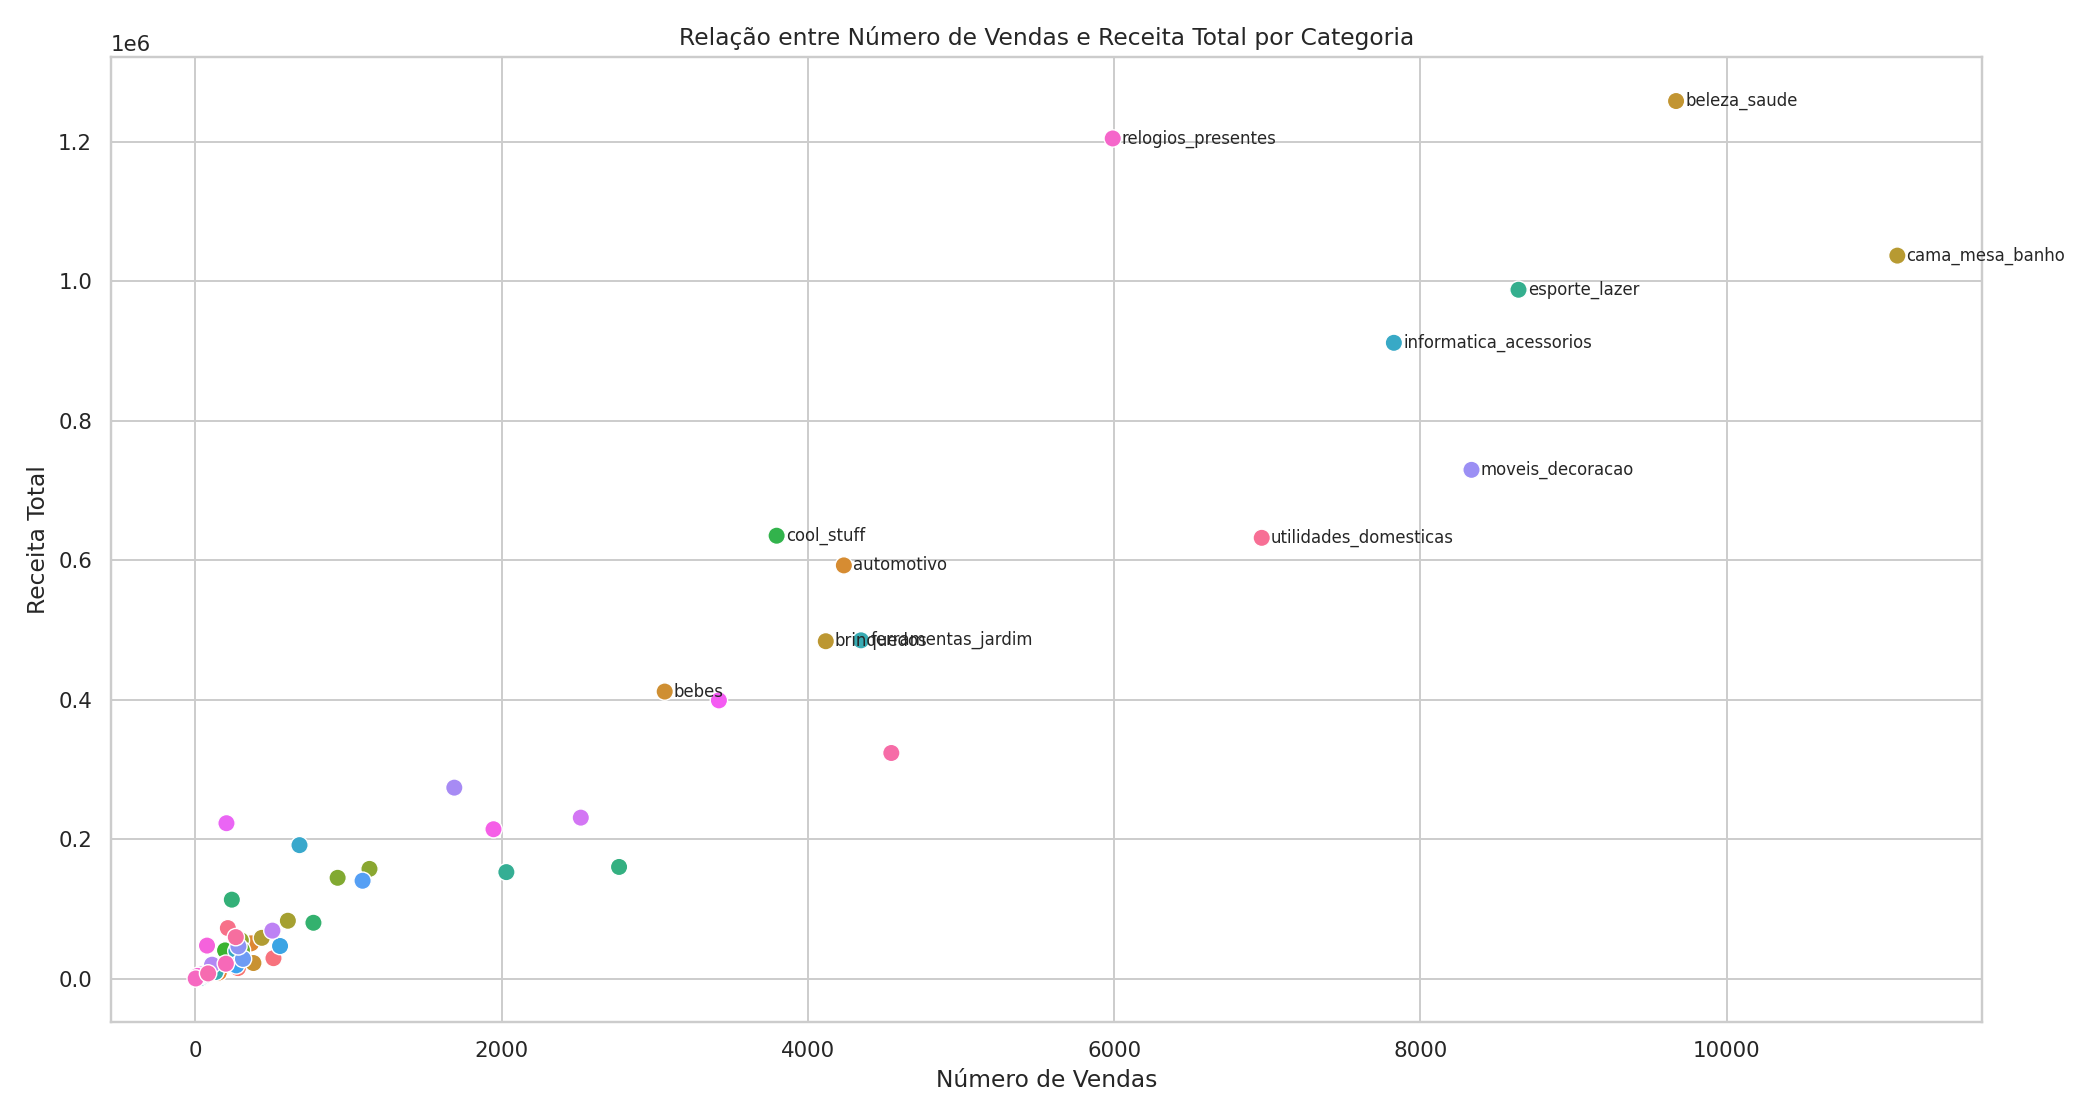

In [1]:
agg = df_items.groupby('product_category_name').agg(
    numero_de_vendas=('order_id', 'count'),
    receita_total=('price', 'sum')
).reset_index() if 'df_items' in dir() else None

# (recalculando a partir de order_items + products para garantir independência da célula anterior)
agg = pd.merge(order_items, products[['product_id', 'product_category_name']], on='product_id', how='left')
agg = agg.dropna(subset=['product_category_name'])
agg = agg.groupby('product_category_name').agg(
    numero_de_vendas=('order_id', 'count'),
    receita_total=('price', 'sum')
).reset_index()

plt.figure(figsize=(15, 8))
palette = sns.color_palette("husl", n_colors=agg['product_category_name'].nunique())
sns.scatterplot(data=agg, x='numero_de_vendas', y='receita_total',
                 hue='product_category_name', palette=palette, s=80, legend=False)

destaque = agg.sort_values('receita_total', ascending=False).head(12)
for _, row in destaque.iterrows():
    plt.text(row['numero_de_vendas'] + 60, row['receita_total'], row['product_category_name'],
              fontsize=8.5, va='center')

plt.title('Relação entre Número de Vendas e Receita Total por Categoria')
plt.xlabel('Número de Vendas'); plt.ylabel('Receita Total')
plt.tight_layout()
plt.show()

print(agg.sort_values('receita_total', ascending=False).head(5).to_string(index=False))

**Insight:** volume de vendas e receita não andam sempre juntos. `relogios_presentes` vende bem menos que `cama_mesa_banho` (5.991 vs. 11.115 unidades), mas gera receita quase tão alta (R$ 1,2M) — ticket médio muito mais alto. Isso separa categorias de **giro** (alto volume, ticket baixo) das de **margem/valor** (baixo volume, ticket alto), o que muda a estratégia de precificação e estoque para cada grupo.

## 4. Prazo de entrega x satisfação do cliente

Nota média (no prazo): 4.28 | Nota média (com atraso): 2.25


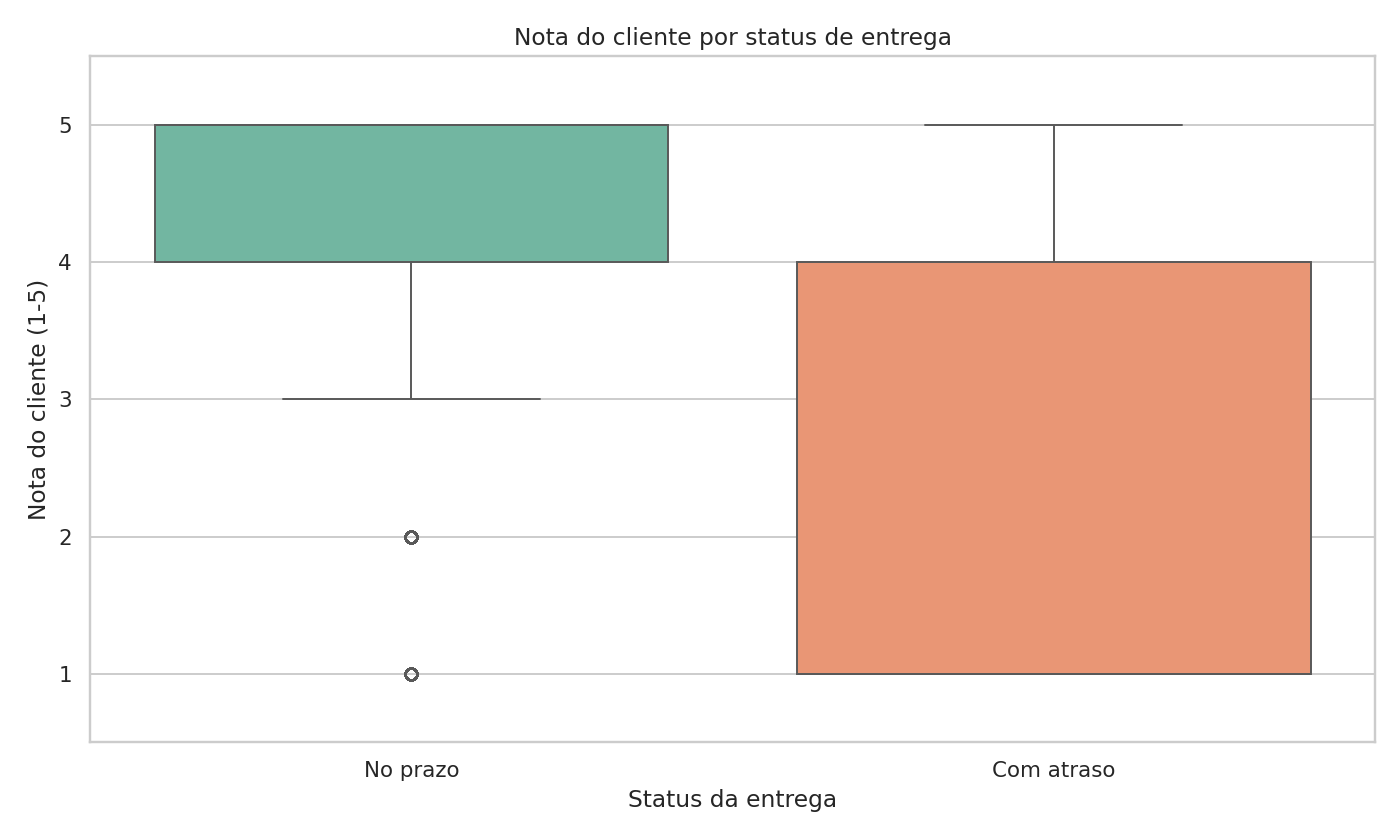

In [1]:
orders_entregues = orders.dropna(subset=['order_delivered_customer_date']).copy()
orders_entregues['atraso_entrega'] = (
    orders_entregues['order_delivered_customer_date'] - orders_entregues['order_estimated_delivery_date']
).dt.days
orders_entregues['entrega_status'] = orders_entregues['atraso_entrega'].apply(
    lambda x: 'Com atraso' if x > 0 else 'No prazo'
)

df_comparacao = pd.merge(
    orders_entregues[['order_id', 'entrega_status']],
    reviews[['order_id', 'review_score']],
    on='order_id'
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparacao, x='entrega_status', y='review_score',
            hue='entrega_status', palette='Set2', legend=False)
plt.title('Nota do cliente por status de entrega')
plt.xlabel('Status da entrega'); plt.ylabel('Nota do cliente (1-5)')
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

media_no_prazo = df_comparacao.loc[df_comparacao['entrega_status'] == 'No prazo', 'review_score'].mean()
media_atraso = df_comparacao.loc[df_comparacao['entrega_status'] == 'Com atraso', 'review_score'].mean()
print(f"Nota média (no prazo): {media_no_prazo:.2f} | Nota média (com atraso): {media_atraso:.2f}")

**Insight:** atraso na entrega é o fator com maior impacto negativo na satisfação — a nota média cai de **4,28 para 2,25** quando o pedido chega atrasado. Prazo de entrega é uma alavanca direta de reputação, não só logística.

## 5. Atrasos e transações interestaduais

Total de pedidos entregues: 96,476
Total de pedidos entregues com atraso: 6,535 (6.8%)
Pedidos com atraso interestaduais: 4,972 de 6,535 (76.1%)


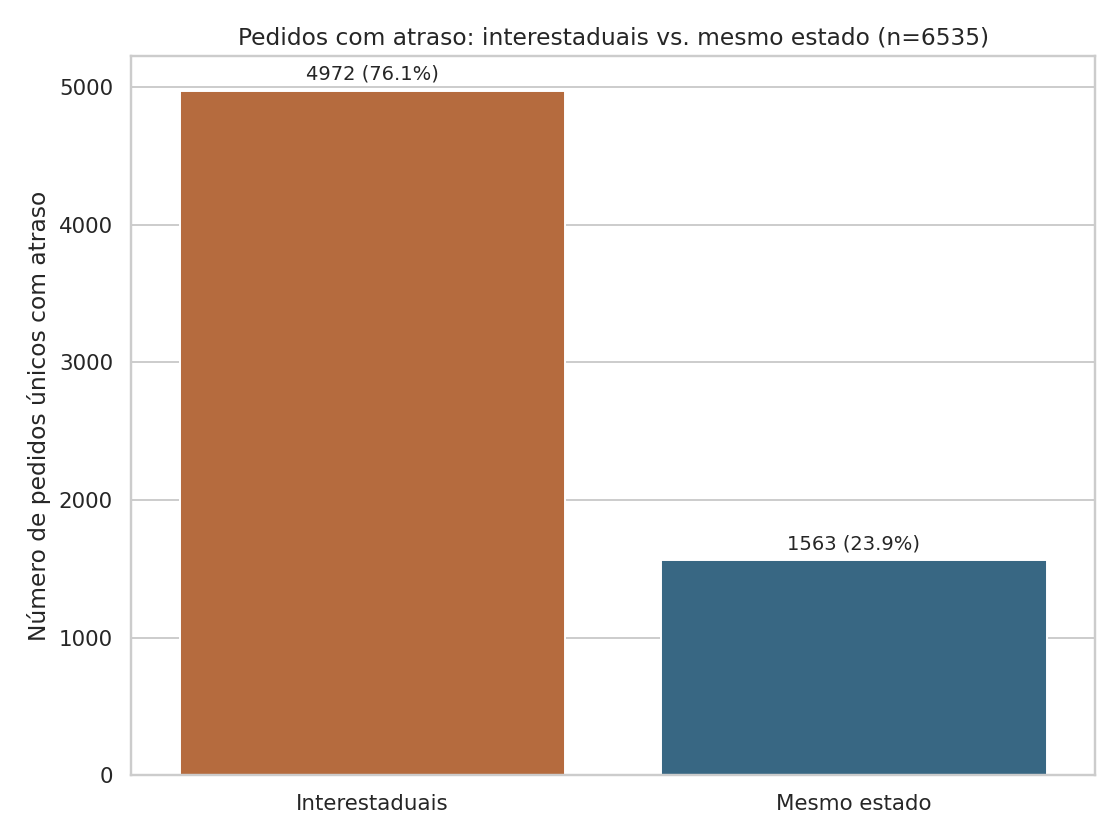

In [1]:
pedidos_com_atraso = orders_entregues[orders_entregues['entrega_status'] == 'Com atraso'].copy()

pedidos_merged = pd.merge(pedidos_com_atraso, customers[['customer_id', 'customer_state']], on='customer_id', how='left')
pedidos_merged = pd.merge(pedidos_merged, order_items[['order_id', 'seller_id']], on='order_id', how='left')
pedidos_merged = pd.merge(pedidos_merged, sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
pedidos_merged.dropna(subset=['customer_state', 'seller_state'], inplace=True)

interestaduais = pedidos_merged[pedidos_merged['customer_state'] != pedidos_merged['seller_state']]
total_atraso = pedidos_com_atraso['order_id'].nunique()
num_inter = interestaduais['order_id'].nunique()
num_intra = total_atraso - num_inter

plt.figure(figsize=(8, 6))
sns.barplot(x=['Interestaduais', 'Mesmo estado'], y=[num_inter, num_intra],
            hue=['Interestaduais', 'Mesmo estado'], palette=['#c9662a', '#2b6a8f'], legend=False)
plt.title(f'Pedidos com atraso: interestaduais vs. mesmo estado (n={total_atraso})')
plt.ylabel('Número de pedidos únicos com atraso')
plt.tight_layout()
plt.show()

print(f"Total de pedidos entregues: {len(orders_entregues):,}")
print(f"Total de pedidos entregues com atraso: {total_atraso:,} ({total_atraso/len(orders_entregues):.1%})")
print(f"Pedidos com atraso interestaduais: {num_inter:,} de {total_atraso:,} ({num_inter/total_atraso:.1%})")

**Insight:** 76% dos pedidos atrasados envolvem comprador e vendedor em estados diferentes — o frete interestadual concentra o risco de atraso e deveria ser o foco prioritário de qualquer ação de melhoria de prazo.

## 6. Perfil do cliente

Estado  Número de Pedidos
    SP              76896
    RJ              23867
    MG              21318
    RS               9939
    PR               9319


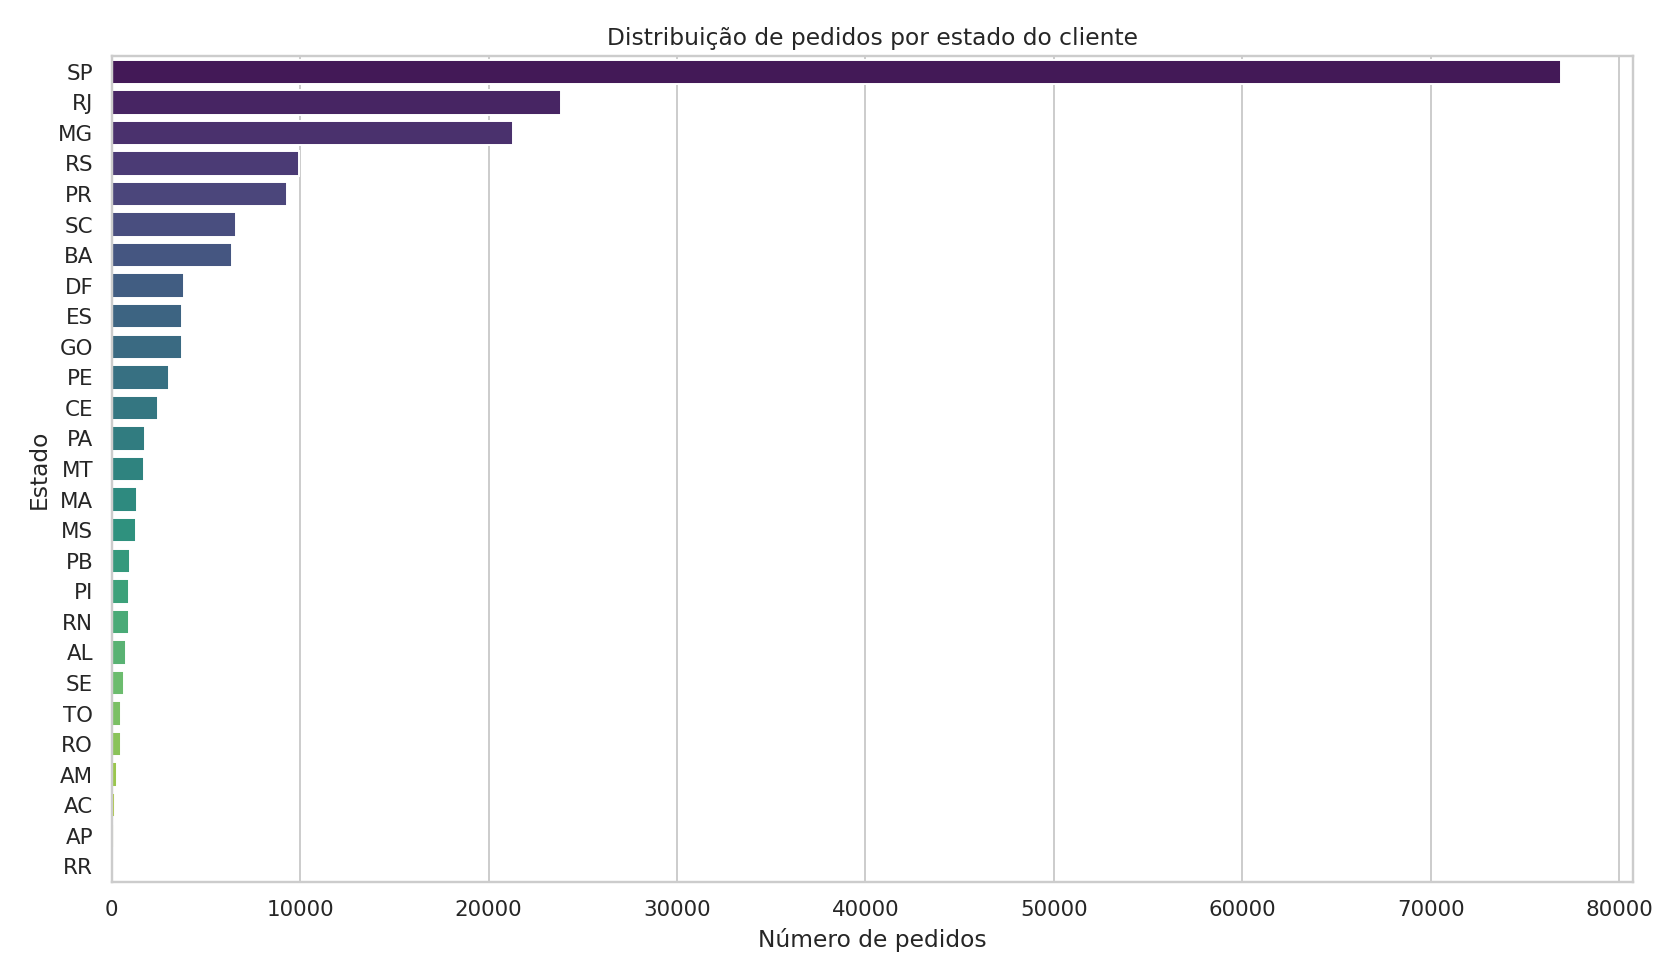

In [1]:
df_full = pd.merge(orders, customers, on='customer_id', how='left')
df_full = pd.merge(df_full, payments, on='order_id', how='left')
df_full = pd.merge(df_full, reviews[['order_id', 'review_score']], on='order_id', how='left')

customer_locations = df_full['customer_state'].value_counts().reset_index()
customer_locations.columns = ['Estado', 'Número de Pedidos']

plt.figure(figsize=(12, 7))
sns.barplot(data=customer_locations, x='Número de Pedidos', y='Estado',
            hue='Estado', palette='viridis', orient='h', legend=False)
plt.title('Distribuição de pedidos por estado do cliente')
plt.tight_layout()
plt.show()

print(customer_locations.head(5).to_string(index=False))

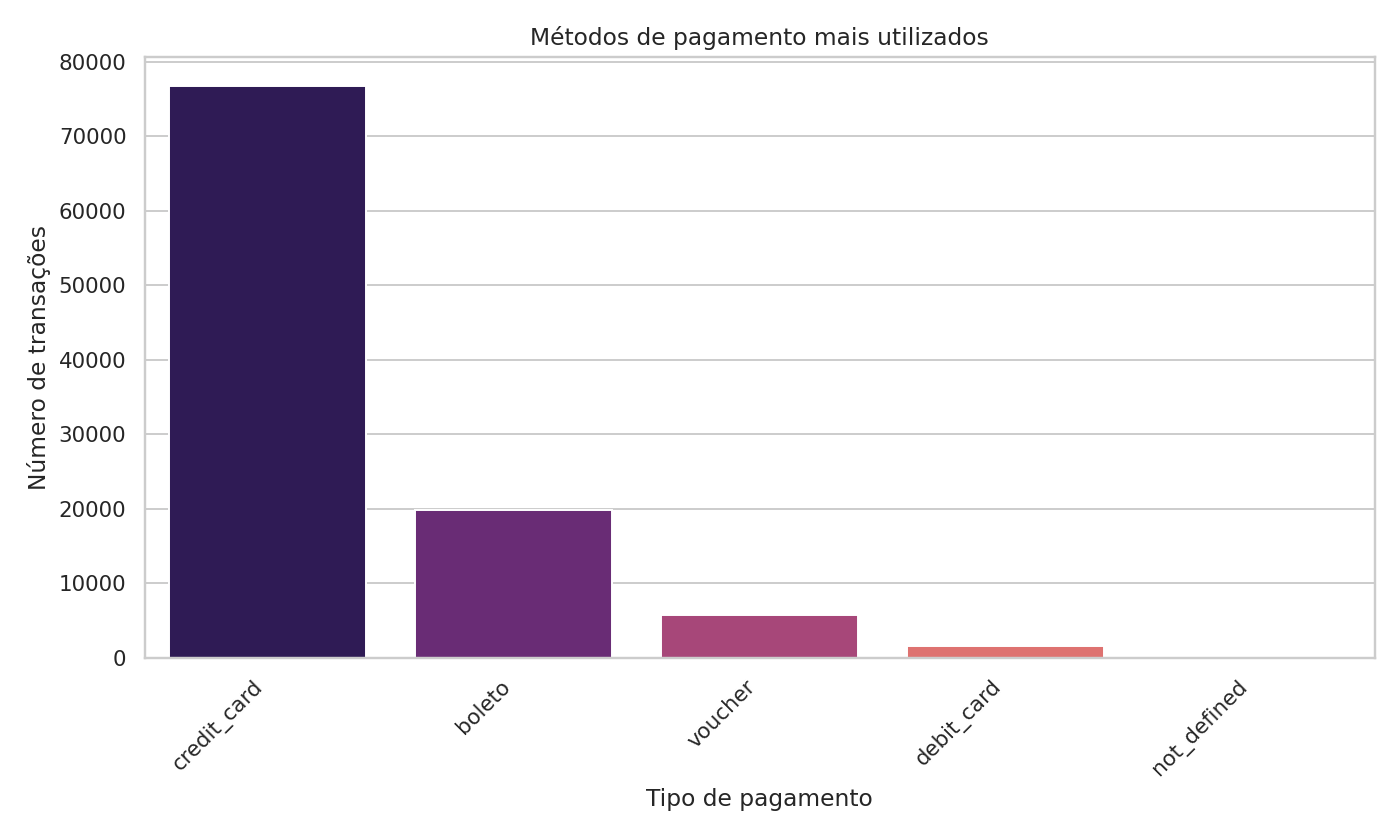

In [1]:
payment_methods = payments['payment_type'].value_counts().reset_index()
payment_methods.columns = ['Tipo de Pagamento', 'Número de Transações']

plt.figure(figsize=(10, 6))
sns.barplot(data=payment_methods, x='Tipo de Pagamento', y='Número de Transações',
            hue='Tipo de Pagamento', palette='magma', legend=False)
plt.title('Métodos de pagamento mais utilizados')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

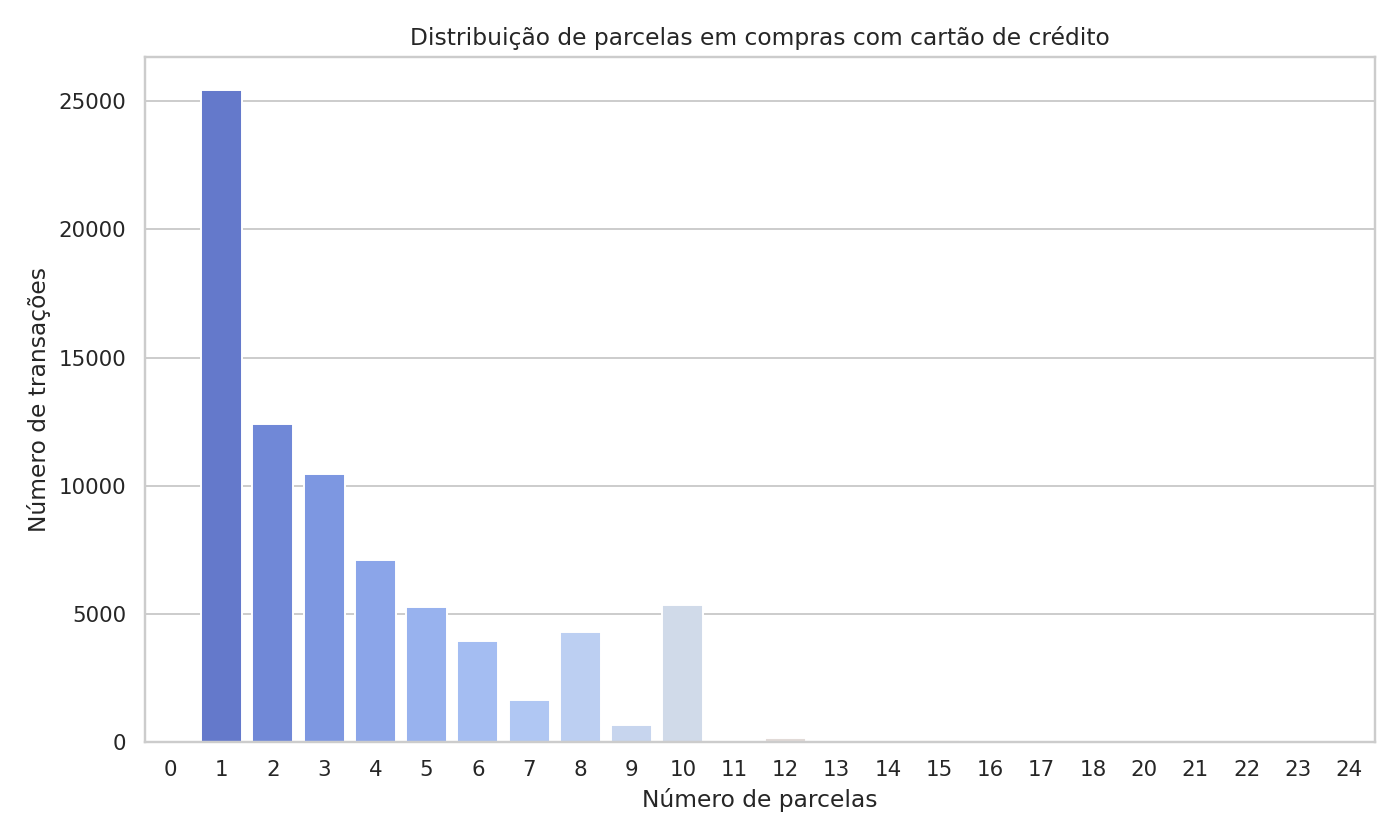

In [1]:
credit_card_payments = payments[payments['payment_type'] == 'credit_card']
installments = credit_card_payments['payment_installments'].value_counts().sort_index().reset_index()
installments.columns = ['Número de Parcelas', 'Contagem']

plt.figure(figsize=(10, 6))
sns.barplot(data=installments, x='Número de Parcelas', y='Contagem',
            hue='Número de Parcelas', palette='coolwarm', legend=False)
plt.title('Distribuição de parcelas em compras com cartão de crédito')
plt.tight_layout()
plt.show()

Nota média de satisfação geral: 4.06


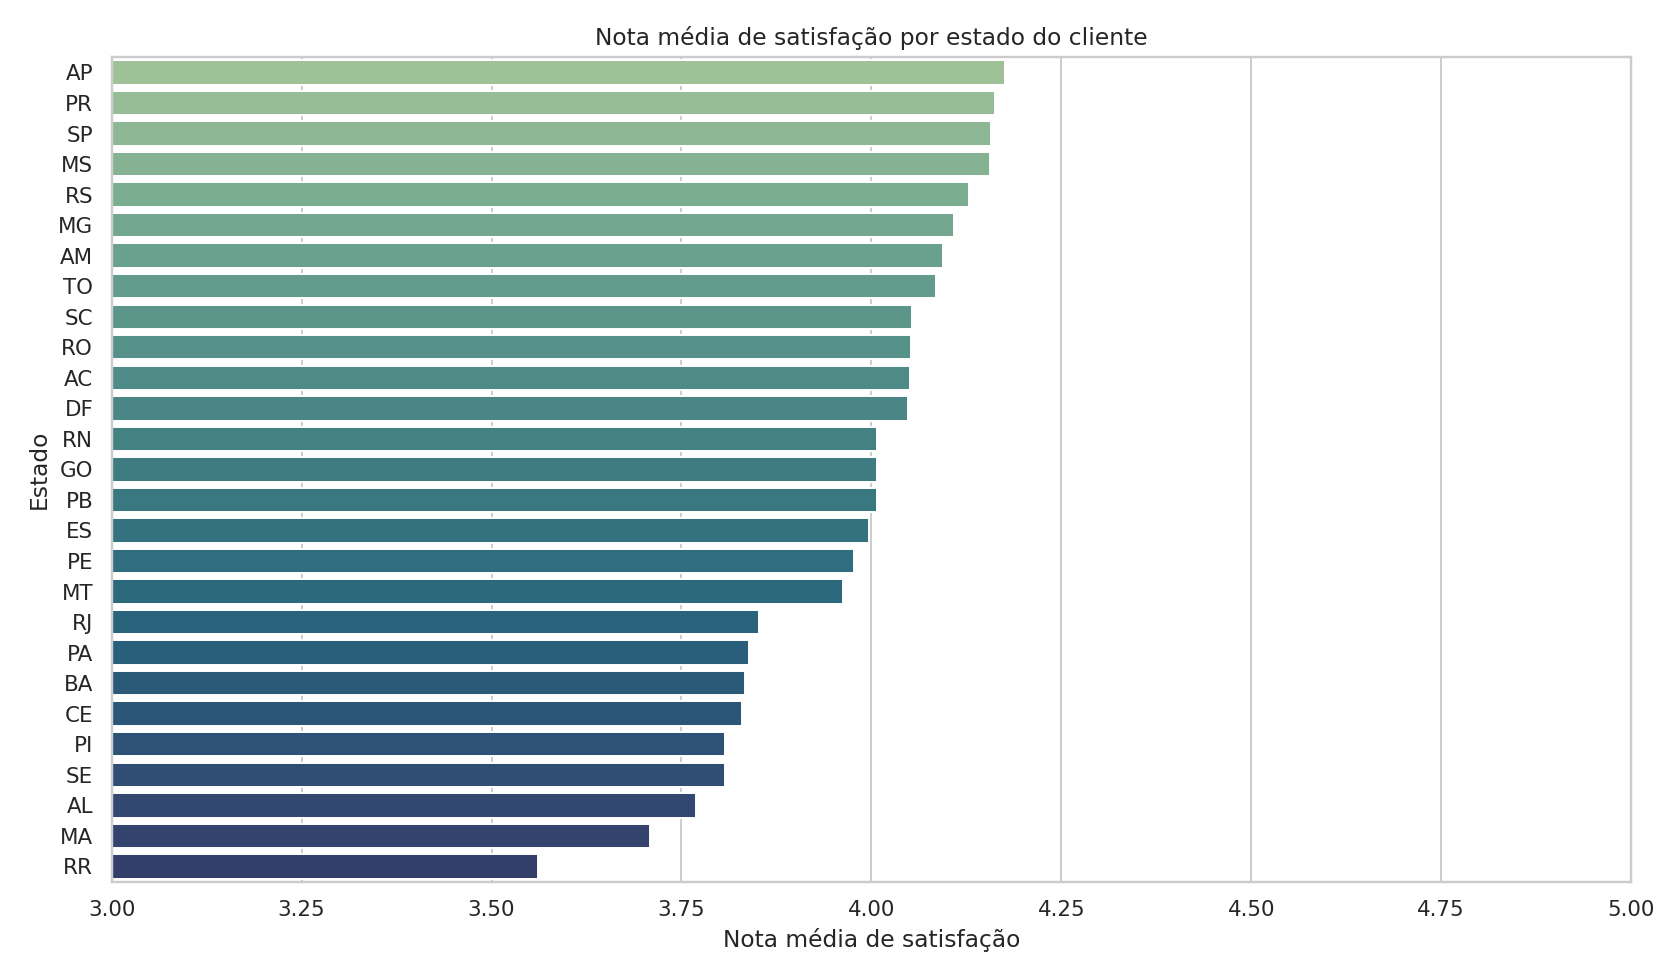

In [1]:
average_score_by_state = df_full.groupby('customer_state')['review_score'].mean().sort_values(ascending=False).reset_index()
average_score_by_state.columns = ['Estado', 'Nota Média de Satisfação']

plt.figure(figsize=(12, 7))
sns.barplot(data=average_score_by_state, x='Nota Média de Satisfação', y='Estado',
            hue='Estado', palette='crest', orient='h', legend=False)
plt.title('Nota média de satisfação por estado do cliente')
plt.xlim(3, 5)
plt.tight_layout()
plt.show()

print(f"Nota média de satisfação geral: {df_full['review_score'].mean():.2f}")

## 7. Conclusões

- **Crescimento consistente**: pedidos e receita cresceram de forma quase contínua entre 2016 e 2018, com pico sazonal em novembro (Black Friday).
- **Categorias-chave**: `cama_mesa_banho`, `beleza_saude` e `esporte_lazer` lideram em volume de vendas — bons candidatos a campanhas e estoque prioritário.
- **Entrega é o principal driver de satisfação**: nota cai de 4,28 para 2,25 quando o pedido atrasa — maior impacto identificado nesta análise.
- **Frete interestadual concentra o risco**: 76% dos atrasos ocorrem em transações entre estados diferentes — ponto prioritário para revisão logística.
- **Cartão de crédito domina os pagamentos**, com forte concentração em parcelamento — relevante para estratégias de precificação e checkout.
- **Concentração geográfica**: SP, RJ e MG respondem pela maior parte dos pedidos, mas não necessariamente pela maior satisfação — vale cruzar volume x nota por estado para priorizar melhorias regionais.

---
**Autor:** Lucas Menezes · [GitHub](https://github.com/L-menezess) · [LinkedIn](https://www.linkedin.com/in/lucasmenezess/)
